# Symbolic Computation with SymPy

**Contents:** 1. symbols · 2. printing · 3. functions · 4. root finding · 5. differentiation and limits · 6. integration · 7. evaluation and NumPy · 8. linear algebra · 9. plotting · **Activity** (4 problems)

We use `sympy` for symbols and `numpy` for numbers. All SymPy commands of this notebook are collected in the separate cheat sheet **`sympy_cheatsheet.pdf`**.

**Installation.** If a package is missing, install it once with `pip`:

| where | command |
|---|---|
| in a terminal / command prompt | `pip install sympy numpy matplotlib` (on some systems `pip3` or `python -m pip`) |
| inside this notebook (a code cell) | `%pip install sympy numpy matplotlib` |
| upgrade an old version | `pip install --upgrade sympy` |

Restart the kernel after installing, then check the versions with the next cell.

In [205]:
# %pip install sympy numpy matplotlib     # uncomment and run once if an import fails

In [206]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math

print("sympy", sp.__version__, "| numpy", np.__version__)

sympy 1.14.0 | numpy 2.5.2


---
## 1. Symbols and expressions

NumPy computes with **numbers**; SymPy computes with **symbols**, so `x**2 + 2*x` stays a formula.

| you want to ... | SymPy |
|---|---|
| one symbol / several symbols | `x = sp.Symbol('x')`, `x, y, z = sp.symbols('x y z')` |
| a **numbered list** $x_1, \ldots, x_n$ | `sp.symbols('x1:6')` gives `(x1, x2, x3, x4, x5)`; for a variable `n`: `sp.symbols(f'x1:{n+1}')` |
| a range of letters | `sp.symbols('a:d')` gives `(a, b, c, d)` |
| a symbol with **assumptions** | `sp.Symbol('t', positive=True)`; also `real=True`, `integer=True`, `nonnegative=True` |
| an exact fraction | `sp.Rational(1, 3)` (but `1/3` is the float `0.333...`) |
| exact constants | `sp.pi`, `sp.E`, `sp.I`, `sp.oo` ($\infty$), `sp.sqrt(2)` |
| expand / factor / simplify | `sp.expand(e)`, `sp.factor(e)`, `sp.simplify(e)` |
| cancel a fraction / partial fractions / group powers | `sp.cancel(e)`, `sp.apart(e, x)`, `sp.collect(e, x)` |
| substitute | `e.subs(x, 2)`, `e.subs({x: 2, y: 3})` |

**Watch out:** Python divides integers **before** SymPy sees them: `x + 1/3` contains a float, `x + sp.Rational(1, 3)` is exact.

**Capital or lowercase?** SymPy follows the Python naming convention:

| style | what it is | examples |
|---|---|---|
| **Capitalised** | a **class**: calling it *creates an object* that SymPy stores and works with | `sp.Symbol`, `sp.Matrix`, `sp.Rational`, `sp.Function`, `sp.Piecewise`, `sp.Eq` |
| **Capitalised**, unevaluated | a class that only *writes* the operation; `.doit()` computes it | `sp.Integral`, `sp.Derivative`, `sp.Sum`, `sp.Limit` |
| **lowercase** | a **function**: it *does* something and returns the result | `sp.symbols`, `sp.diff`, `sp.integrate`, `sp.solve`, `sp.simplify`, `sp.latex` |
| lowercase math functions | written as in mathematics | `sp.sqrt`, `sp.exp`, `sp.sin`, `sp.log` |
| constants | `E` and `I` are capital so they do not clash with your own variables `e`, `i` | `sp.pi`, `sp.oo`, `sp.E`, `sp.I` |

Many come in pairs: `sp.Symbol('x')` (one object) vs. `sp.symbols('x y')` (helper for several); `sp.Integral(f, x)` (written $\int f\,dx$) vs. `sp.integrate(f, x)` (computed).

In [207]:
x, y = sp.symbols('x y')
X = sp.symbols('x1:6')                     # tuple (x1, ..., x5)
print("numbered symbols:", X, "   sum:", sum(X))
print("as a list       :", list(sp.symbols('a0:3')))

expr = (x + y)**2 - x * (x - 1)
print("1/3 vs Rational :", x + 1/3, "  |  ", x + sp.Rational(1, 3))
print("expand          :", sp.expand((x + 1)**3))
print("factor          :", sp.factor(x**3 - x))
print("simplify        :", sp.simplify(sp.sin(x)**2 + sp.cos(x)**2))
print("cancel / apart  :", sp.cancel((x**2 - 1) / (x - 1)), "  |  ", sp.apart(1 / (x * (x + 1)), x))
print("collect         :", sp.collect(x**2 + 3*x*y + x + y*x**2, x))
print("subs            :", expr.subs({x: 2, y: 3}), "  |  ", expr.subs(y, sp.sin(x)))

numbered symbols: (x1, x2, x3, x4, x5)    sum: x1 + x2 + x3 + x4 + x5
as a list       : [a0, a1, a2]
1/3 vs Rational : x + 0.333333333333333   |   x + 1/3
expand          : x**3 + 3*x**2 + 3*x + 1
factor          : x*(x - 1)*(x + 1)
simplify        : 1
cancel / apart  : x + 1   |   -1/(x + 1) + 1/x
collect         : x**2*(y + 1) + x*(3*y + 1)
subs            : 23   |   -x*(x - 1) + (x + sin(x))**2


**Assumptions matter.** $\sqrt{x^2} = x$ is false for $x = -2$, so SymPy simplifies it only when it knows the sign.

In [208]:
for label, s in [("no assumptions", sp.Symbol('x')), ("real=True", sp.Symbol('x', real=True)),
                 ("positive=True", sp.Symbol('x', positive=True))]:
    print(f"{label:>15}:  sqrt(x**2) ->", sp.simplify(sp.sqrt(s**2)))
k = sp.Symbol('k', integer=True)
print("cos(2*pi*k), k integer:", sp.cos(2 * sp.pi * k))

 no assumptions:  sqrt(x**2) -> sqrt(x**2)
      real=True:  sqrt(x**2) -> Abs(x)
  positive=True:  sqrt(x**2) -> x
cos(2*pi*k), k integer: 1


**Python reminder: building a list with a loop, and the short form.** Later cells and hints often need "do something for every item of a list". The basic way is a `for` loop that starts with an empty list and **appends** one result per item. Python also has a one-line short form, the **list comprehension** `[expression for item in some_list]`, read as "the list of *expression* for every *item* in *some_list*". Both give the same list; use whichever you find clearer.

| loop with `append` | list comprehension |
|---|---|
| `out = []`<br>`for v in [1, 2, 3]:`<br>`    out.append(v**2)` | `out = [v**2 for v in [1, 2, 3]]` |
| `out = []`<br>`for v in vals:`<br>`    if v > 0:`<br>`        out.append("pos")`<br>`    else:`<br>`        out.append("neg")` | `out = ["pos" if v > 0 else "neg" for v in vals]` |
| `total = 0`<br>`for v in vals:`<br>`    total = total + v**2` | `total = sum(v**2 for v in vals)` |

To turn a list of SymPy numbers into a NumPy array you need neither: `np.array(sp_list, dtype=float)`.

In [209]:
vals = [-2, 0, 3]
out = []                                  # loop version
for v in vals:
    out.append(x**2 - v)
print("loop          :", out)
print("comprehension :", [x**2 - v for v in vals])
print("to NumPy      :", np.array([sp.sqrt(2), sp.pi, sp.Rational(1, 3)], dtype=float))

loop          : [x**2 + 2, x**2, x**2 - 3]
comprehension : [x**2 + 2, x**2, x**2 - 3]
to NumPy      : [1.41421356 3.14159265 0.33333333]


---
## 2. Printing: `print`, `pprint`, `init_printing`, `display`, `latex`

| command | output | use it for |
|---|---|---|
| `print(e)` | plain text, `x**2 + 1` | logs, copying into Python |
| `sp.pprint(e)` | ASCII art | a quick look without LaTeX |
| `sp.init_printing()` | from now on the **last line of a cell** is rendered as math | working in Jupyter |
| `display(e)` | rendered math from anywhere in a cell | several formulas in one cell |
| `sp.latex(e)` | a **string** of LaTeX, `x^{2} + 1` | reports, Markdown, plot titles |
| `sp.latex(e, mode='inline')` | `$x^{2} + 1$` | Markdown, Matplotlib |
| `sp.latex(e, mode='equation')` | `\begin{equation}x^{2} + 1\end{equation}` (numbered) | pasting into a `.tex` report |
| `sp.latex(e, mode='equation*')` | `\begin{equation*}...\end{equation*}` (unnumbered) | same |
| `sp.latex(sp.Eq(lhs, rhs))` | `lhs = rhs` | writing an equation |
| `sp.latex(M, mat_str='pmatrix', mat_delim='')` | `\begin{pmatrix}...\end{pmatrix}` | matrices with round brackets |
| `display(Math(s))` | renders a LaTeX string `s` | your own LaTeX mixed with `sp.latex` |

**Watch out:** `print()` is always plain text, even after `init_printing()`. To use an environment like `align` that SymPy does not produce, build the string yourself: `r"\begin{align}" + ... + r"\end{align}"`.

In [210]:
e = sp.Integral(sp.sqrt(x) / (1 + x**2), (x, 0, sp.oo))
print("print  :", e)
sp.pprint(e)
print("latex  :", sp.latex(e))
print("inline :", sp.latex(e, mode='inline'))
print("equat. :", sp.latex(sp.Eq(sp.Symbol('I'), e), mode='equation'))
print("matrix :", sp.latex(sp.Matrix([[1, x], [0, 1]]), mat_str='pmatrix', mat_delim=''))
lines = [sp.latex(sp.Eq(sp.Function('f')(x), x**2)), sp.latex(sp.Eq(sp.Derivative(sp.Function('f')(x), x), 2*x))]
print("align  :", r"\begin{align}" + r" \\ ".join(l.replace("=", "&=", 1) for l in lines) + r"\end{align}")

print  : Integral(sqrt(x)/(x**2 + 1), (x, 0, oo))
∞          
⌠          
⎮   √x     
⎮ ────── dx
⎮  2       
⎮ x  + 1   
⌡          
0          
latex  : \int\limits_{0}^{\infty} \frac{\sqrt{x}}{x^{2} + 1}\, dx
inline : $\int_{0}^{\infty} \frac{\sqrt{x}}{x^{2} + 1}\, dx$
equat. : \begin{equation}I = \int\limits_{0}^{\infty} \frac{\sqrt{x}}{x^{2} + 1}\, dx\end{equation}
matrix : \begin{pmatrix}1 & x\\0 & 1\end{pmatrix}
align  : \begin{align}f{\left(x \right)} &= x^{2} \\ \frac{d}{d x} f{\left(x \right)} &= 2 x\end{align}


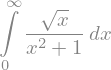

<IPython.core.display.Math object>

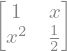

In [211]:
sp.init_printing()                 # rendered math for the rest of the notebook
display(e)
display(Math(r"I = " + sp.latex(e.doit())))
sp.Matrix([[1, x], [x**2, sp.Rational(1, 2)]])      # last line: rendered automatically

---
## 3. Functions

| kind | how | use it for |
|---|---|---|
| **expression** | `f_expr = x**2 * sp.exp(-x)`, then `f_expr.subs(x, 3)` | most work: diff, integrate, solve |
| **Python function** returning an expression | `def f(t): return t**2 * sp.exp(-t)` | building expressions programmatically |
| `sp.Lambda` | `f = sp.Lambda(x, x**2 * sp.exp(-x))`, then `f(3)` | a function object inside SymPy |
| **undefined function** (one) | `f = sp.Function('f')`, then `f(x).diff(x)` | unknown functions, ODEs |
| **several** undefined functions | `f, g = sp.symbols('f g', cls=sp.Function)` | same, many at once |
| **numbered** undefined functions | `u = sp.symbols('u1:4', cls=sp.Function)` gives `(u1, u2, u3)` | systems of ODEs, families of functions |
| **piecewise** | `sp.Piecewise((expr1, cond1), (expr2, cond2), ..., (exprN, True))` | functions defined by cases |

**Several functions with `cls`.** `sp.symbols` normally creates `Symbol` objects. The keyword `cls` (short for *class*) tells it which class to create instead: with `cls=sp.Function` every name becomes an undefined function, so all the shortcuts of `sp.symbols` (several names, numbered ranges like `'u1:4'`) work for functions too. Each one must be **called** with its argument before use: `f(x)`, `u[0](t)`.

**Piecewise.** The pairs are checked **in order**; the first true condition wins, and `True` at the end means "otherwise". Conditions are SymPy relations (`x < 0`, `x >= 1`, `sp.Eq(x, 0)`), combined with

| logic | SymPy | operator form |
|---|---|---|
| and | `sp.And(0 <= x, x < 1)` | `(0 <= x) & (x < 1)` |
| or | `sp.Or(x < -1, x > 1)` | `(x < -1) \| (x > 1)` |
| not | `sp.Not(x < 0)` | `~(x < 0)` |

**Watch out:** Python's `and`, `or` and the chained `0 <= x < 1` do **not** work on symbols: they raise `TypeError: cannot determine truth value of Relational`. With the operator form, the parentheses are required.

**Example with three pieces:** $\;p(x) = \begin{cases} -x & x < 0 \\ x^2 & 0 \le x < 1 \\ x & \text{otherwise} \end{cases}$

u = (u1, u2, u3)   u[0](x) = u1(x)


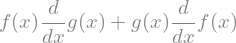

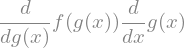

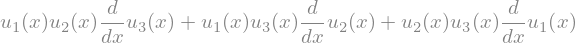

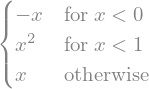

p at -2, 1/2, 3: [2, 1/4, 3]
LaTeX (cases environment): \begin{cases} - x & \text{for}\: x < 0 \\x^{2} & \text{for}\: x < 1 \\x & \text{otherwise} \end{cases}
outside [-1, 1] at -2, 0, 2: [1, 0, 1]
on a NumPy array: [2.   0.25 3.  ]


In [212]:
f_expr = x**2 * sp.exp(-x)
def f_py(t):
    return t**2 * sp.exp(-t)
f_lam = sp.Lambda(x, x**2 * sp.exp(-x))
display(f_expr.subs(x, 3), f_py(3), f_lam(3), f_py(y + 1))

f = sp.Function('f')                                # one undefined function
f, g = sp.symbols('f g', cls=sp.Function)          # several at once
u = sp.symbols('u1:4', cls=sp.Function)            # numbered: (u1, u2, u3)
print("u =", u, "  u[0](x) =", u[0](x))
display(sp.diff(f(x) * g(x), x), sp.diff(f(g(x)), x))
display(sp.diff(u[0](x) * u[1](x) * u[2](x), x))   # product rule for three functions
display(sp.dsolve(f(x).diff(x, 2) + f(x), f(x)))    # ODE f'' + f = 0

p = sp.Piecewise((-x, x < 0), (x**2, sp.And(0 <= x, x < 1)), (x, True))
display(p)                                          # 0 <= x is dropped: x < 0 was already handled
print("p at -2, 1/2, 3:", [p.subs(x, v) for v in (-2, sp.Rational(1, 2), 3)])
print("LaTeX (cases environment):", sp.latex(p))
outside = sp.Piecewise((1, sp.Or(x < -1, x > 1)), (0, True))
print("outside [-1, 1] at -2, 0, 2:", [outside.subs(x, v) for v in (-2, 0, 2)])
print("on a NumPy array:", sp.lambdify(x, p, 'numpy')(np.array([-2, 0.5, 3])))

---
## 4. Root finding

| function | returns | when |
|---|---|---|
| `sp.solve(e, x)` | a **list** of exact solutions of $e = 0$ | polynomials, simple equations |
| `sp.solve(sp.Eq(lhs, rhs), x)` | same, for $\text{lhs} = \text{rhs}$ | |
| `sp.solve([e1, e2], [x, y])` | a **dict** (or list of dicts) | systems |
| `sp.solveset(e, x, domain=sp.S.Reals)` | a **set**, possibly infinite or empty | all solutions on a domain |
| `sp.roots(p, x)` | `{root: multiplicity}` | polynomials |
| `sp.real_roots(p)` | list of real roots | polynomials |
| `sp.nsolve(e, x, x0)` | **one number**, Newton's method from the guess `x0` | no formula exists (e.g. $\cos x = x$) |

**Strategy:** try `solve`; if the answer is huge or SymPy gives up, use `nsolve` with a guess read off a plot.

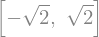

In [213]:
display(sp.solve(x**2 - 5*x + 6, x), sp.solve(sp.Eq(x**2, 2), x))
display(sp.solve([x + y - 3, x - y - 1], [x, y]))
display(sp.roots((x - 1)**3 * (x + 2), x))
display(sp.solveset(sp.sin(x), x, domain=sp.S.Reals), sp.solveset(x**2 + 1, x, domain=sp.S.Reals))
display(sp.nsolve(sp.cos(x) - x, x, 1))

---
## 5. Differentiation and limits

| mathematics | SymPy |
|---|---|
| $\dfrac{df}{dx} = f'(x)$ | `sp.diff(f, x)` or `f.diff(x)` |
| $\dfrac{d^2 f}{dx^2} = f''(x)$, $\;\dfrac{d^n f}{dx^n}$ | `sp.diff(f, x, 2)`, `sp.diff(f, x, n)` |
| $\dfrac{\partial F}{\partial y}$ | `sp.diff(F, y)` |
| $\dfrac{\partial^2 F}{\partial x\,\partial y}$ | `sp.diff(F, x, y)` |
| $\dfrac{\partial^3 F}{\partial x^2\,\partial y}$ (2nd power in $x$, 1st in $y$) | `sp.diff(F, x, 2, y)` or `sp.diff(F, x, x, y)` |
| $\dfrac{d}{dx} f$ written but **not** evaluated | `sp.Derivative(f, x)`, then `.doit()` |
| $\nabla F = \left(\dfrac{\partial F}{\partial x}, \dfrac{\partial F}{\partial y}\right)$ | `[sp.diff(F, v) for v in (x, y)]` |
| Hessian $\begin{pmatrix} F_{xx} & F_{xy} \\ F_{yx} & F_{yy} \end{pmatrix}$ | `sp.hessian(F, (x, y))` |
| Taylor series $\displaystyle\sum_{k=0}^{n-1} \frac{f^{(k)}(x_0)}{k!}(x - x_0)^k + O\big((x-x_0)^n\big)$ | `sp.series(f, x, x0, n)`; `.removeO()` drops the $O(\cdot)$ |
| tangent line $y = f(x_0) + f'(x_0)(x - x_0)$ | `f.subs(x, x0) + sp.diff(f, x).subs(x, x0) * (x - x0)` |
| right limit $\displaystyle\lim_{x \to x_0^+} f(x)$ | `sp.limit(f, x, x0)` (**default**, same as `dir='+'`) |
| left limit $\displaystyle\lim_{x \to x_0^-} f(x)$ | `sp.limit(f, x, x0, dir='-')` |
| two-sided limit $\displaystyle\lim_{x \to x_0} f(x)$ | `sp.limit(f, x, x0, dir='+-')` (error if left $\ne$ right) |
| $\displaystyle\lim_{x \to \infty} f(x)$ | `sp.limit(f, x, sp.oo)` |

**Watch out:**
- `sp.limit` without `dir` is the **right** limit. For $|x|/x$ at $0$ it returns $1$, although the two-sided limit does not exist.
- `sp.limit` is **not reliable on a `Piecewise`** at a break point. Take the limit of the piece that applies on each side instead: for the left limit at a break, use the piece to the left with `dir='-'`.

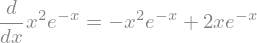

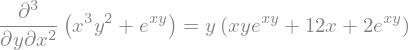

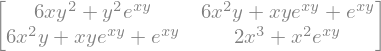

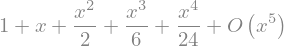

right: 1   left: -1
two-sided: The limit does not exist since left hand limit = -1 and right hand limit = 1
sin(x)/x two-sided: 1    (1+1/x)^x at oo: E


In [214]:
f_expr = x**2 * sp.exp(-x)
d = sp.Derivative(f_expr, x)
display(sp.Eq(d, d.doit()), sp.factor(sp.diff(f_expr, x, 2)))

F = x**3 * y**2 + sp.exp(x * y)
d3 = sp.Derivative(F, x, 2, y)                   # d^3 F / dx^2 dy
display(sp.Eq(d3, sp.factor(d3.doit())))
display([sp.diff(F, v) for v in (x, y)], sp.hessian(F, (x, y)))
display(sp.series(sp.exp(x), x, 0, 5))

s = sp.Abs(x) / x
print("right:", sp.limit(s, x, 0), "  left:", sp.limit(s, x, 0, dir='-'))
try:
    sp.limit(s, x, 0, dir='+-')
except ValueError as err:
    print("two-sided:", err)
print("sin(x)/x two-sided:", sp.limit(sp.sin(x) / x, x, 0, dir='+-'), "   (1+1/x)^x at oo:", sp.limit((1 + 1/x)**x, x, sp.oo))

---
## 6. Integration

| you want | SymPy |
|---|---|
| antiderivative $\int f\,dx$ (SymPy does **not** add $+C$) | `sp.integrate(f, x)` |
| definite $\int_a^b f\,dx$ | `sp.integrate(f, (x, a, b))` |
| improper, $\int_0^\infty$ | `sp.integrate(f, (x, 0, sp.oo))` |
| double integral $\int_0^1\!\int_0^x f\,dy\,dx$ | `sp.integrate(f, (y, 0, x), (x, 0, 1))` (inner first) |
| unevaluated (for display) | `sp.Integral(f, (x, a, b))`, then `.doit()` |
| numerical value | `.evalf()` |

**Check an antiderivative** by differentiating it: `sp.simplify(sp.diff(F, x) - f)` should be `0`.

**No elementary formula?** SymPy may answer with a special function ($\operatorname{erf}$, $\operatorname{Si}$, ...) or return the `Integral` unevaluated. Either way `.evalf()` still gives a number.

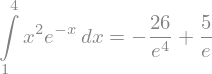

In [215]:
f_expr = x**2 * sp.exp(-x)
F = sp.integrate(f_expr, x)
display(F, sp.simplify(sp.diff(F, x) - f_expr))           # check: 0

I = sp.Integral(f_expr, (x, 1, 4))
display(sp.Eq(I, I.doit()), I.evalf())

display(sp.integrate(sp.exp(-x**2), (x, -sp.oo, sp.oo)))   # Gaussian: sqrt(pi)
display(sp.integrate(x * y, (y, 0, x), (x, 0, 1)))          # double integral

hard = sp.integrate(sp.sin(x) / x, (x, 0, 1))               # special function Si
display(hard, hard.evalf(20))

---
## 7. Evaluation and moving to NumPy

| you want | SymPy | result type |
|---|---|---|
| plug in exact values | `e.subs({x: 2})` | SymPy (exact) |
| a decimal with $n$ digits | `e.evalf(n)` or `sp.N(e, n)` | SymPy `Float` |
| plug in **and** evaluate | `e.evalf(subs={x: 2})` | SymPy `Float` |
| a Python float | `float(e)` (only when no symbols are left) | `float` |
| a fast **NumPy function** | `f_np = sp.lambdify(x, e, 'numpy')` | works on arrays |
| several variables | `sp.lambdify((x, y), e, 'numpy')` | `f_np(xs, ys)` |
| a matrix as an array | `np.array(M, dtype=float)` | `ndarray` |

**Why `lambdify`?** `subs` walks the symbolic tree for every single value: slow. `lambdify` translates the formula **once** into NumPy code (`sp.exp` becomes `np.exp`, ...), which then runs on a whole array at once.

**Watch out:**
- `np.exp(x)` on a **symbol** fails: use `sp.exp` for symbols, `np.exp` for arrays.
- A **constant** expression lambdifies to a function that returns a **scalar**, not an array: `sp.lambdify(x, sp.Integer(3))(xs)` is `3`. Use `np.full_like(xs, ...)` or add `0 * xs` before plotting.

In [216]:
import time

f_expr = x**2 * sp.exp(-x)
display(f_expr.subs(x, 2), f_expr.subs(x, 2).evalf(), sp.N(f_expr.subs(x, 2), 30), float(f_expr.subs(x, 2)))

f_np = sp.lambdify(x, f_expr, 'numpy')
xs = np.linspace(0, 8, 2000)

t0 = time.perf_counter(); slow = [float(f_expr.subs(x, v)) for v in xs]; t1 = time.perf_counter()
fast = f_np(xs);                                                         t2 = time.perf_counter()
print(f"subs in a loop: {t1 - t0:.4f} s,   lambdify: {t2 - t1:.6f} s,   same values: {np.allclose(slow, fast)}")

F2 = sp.lambdify((x, y), sp.sin(x) * sp.cos(y), 'numpy')     # two variables
print("F2(0.5, [0, 1, 2]) =", F2(0.5, np.array([0, 1, 2])))

const = sp.lambdify(x, sp.diff(3 * x, x), 'numpy')            # derivative is the constant 3
print("constant lambdified on an array:", const(xs[:4]), "  -> use np.full_like:", np.full_like(xs[:4], const(xs[:4])))

M = sp.Matrix([[1, sp.Rational(1, 2)], [sp.sqrt(2), sp.pi]])
print("Matrix -> NumPy:\n", np.array(M, dtype=float))

subs in a loop: 0.6868 s,   lambdify: 0.000108 s,   same values: True
F2(0.5, [0, 1, 2]) = [ 0.47942554  0.25903472 -0.19951142]
constant lambdified on an array: 3   -> use np.full_like: [3. 3. 3. 3.]
Matrix -> NumPy:
 [[1.         0.5       ]
 [1.41421356 3.14159265]]


---
## 8. Linear algebra with `sp.Matrix`

SymPy matrices are **exact**: no rounding in an RREF, a determinant is an exact integer or formula, and entries can be symbols.

| you want | SymPy |
|---|---|
| a matrix / identity / zeros | `sp.Matrix([[1, 2], [3, 4]])`, `sp.eye(n)`, `sp.zeros(m, n)` |
| transpose, inverse | `A.T`, `A.inv()` |
| **matrix** product, power | `A @ B`, `A**3` (scalar times matrix: `2 * A`) |
| **elementwise** product (Hadamard) | `A.multiply_elementwise(B)` |
| apply a function to every entry | `A.applyfunc(lambda e: e**2)` |
| determinant, rank | `A.det()`, `A.rank()` |
| reduced row echelon form | `R, pivots = A.rref()` |
| null space / column space | `A.nullspace()`, `A.columnspace()` (lists of column vectors) |
| eigenvalues | `A.eigenvals()` gives `{eigenvalue: algebraic multiplicity}` |
| eigenvectors | `A.eigenvects()` gives `[(eigenvalue, multiplicity, [basis vectors]), ...]` |
| **eigenspace** of $\lambda$ | `(A - lam * sp.eye(n)).nullspace()` |
| diagonalize $A = P D P^{-1}$ | `P, D = A.diagonalize()` |

**Watch out:** we write the matrix product as `A @ B`. It means the same for SymPy matrices and NumPy arrays. (`A * B` is also the matrix product for SymPy matrices, but **elementwise** for NumPy arrays, so `@` avoids confusion.)

**Eigenspace dimension.** The algebraic multiplicity of $\lambda$ (how often it is a root of $\det(A - \lambda I)$) can be larger than the geometric multiplicity (the dimension of the eigenspace). $A$ is diagonalizable exactly when they agree for every $\lambda$.

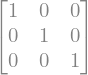

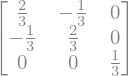

lambda = 1: algebraic multiplicity 1, eigenspace dimension 1
lambda = 3: algebraic multiplicity 2, eigenspace dimension 2


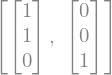

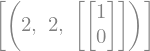

False

In [217]:
A = sp.Matrix([[2, 1, 0],
               [1, 2, 0],
               [0, 0, 3]])

R, piv = A.rref()
display(R, piv, A.det(), A.rank(), A.inv())

display(A.eigenvals())                          # {1: 1, 3: 2}
for lam, mult, vecs in A.eigenvects():
    print(f"lambda = {lam}: algebraic multiplicity {mult}, eigenspace dimension {len(vecs)}")
display((A - 3 * sp.eye(3)).nullspace())        # eigenspace of 3 by hand

J = sp.Matrix([[2, 1], [0, 2]])                 # a Jordan block: NOT diagonalizable
display(J.eigenvects(), J.is_diagonalizable())

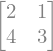

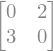

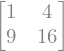

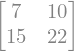

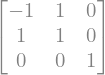

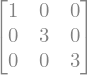

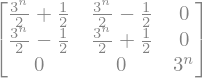

True

In [218]:
B = sp.Matrix([[1, 2], [3, 4]])
C = sp.Matrix([[0, 1], [1, 0]])
display(B @ C, B.multiply_elementwise(C), B.applyfunc(lambda e: e**2), B**2)

# symbolic power A**n through diagonalization
n = sp.Symbol('n', integer=True, nonnegative=True)
P, D = A.diagonalize()
display(P, D)
An = sp.simplify(P @ D**n @ P.inv())
display(An, An.subs(n, 4) == A**4)

# symbolic entries: for which a is S singular?
a = sp.Symbol('a')
S = sp.Matrix([[1, a], [a, 4]])
display(S.det(), sp.solve(S.det(), a))

---
## 9. Plotting symbolic results with Matplotlib

The recipe: **compute symbolically, lambdify, plot numerically, label with `sp.latex`**. Matplotlib understands LaTeX between `$...$` in titles and labels.

Below: $f(x) = x^2 e^{-x}$ with the area $\int_1^4 f\,dx$ shaded, and the exact value in the title.

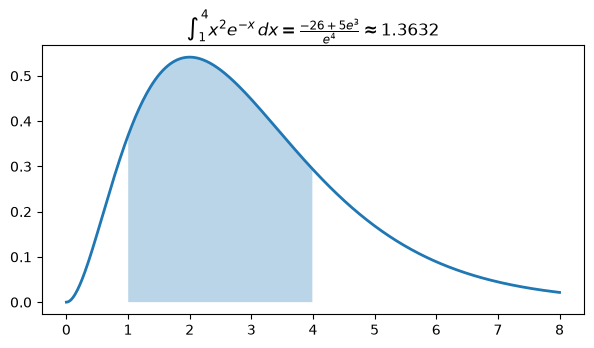

In [219]:
f_expr = x**2*sp.exp(-x)
f_np = sp.lambdify(x, f_expr, 'numpy')
xs = np.linspace(0, 8, 400)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(xs, f_np(xs), lw=2)
mask = (xs >= 1) & (xs <= 4)
ax.fill_between(xs[mask], f_np(xs[mask]), alpha=0.3)
area = sp.integrate(f_expr, (x, 1, 4))
ax.set_title(f"$\\int_1^4 {sp.latex(f_expr)}\\,dx = {sp.latex(sp.simplify(area))} \\approx {float(area):.4f}$")
plt.show()

A second example: a function, its derivative, and the critical point found with `solve`, all from **one** symbolic expression. The legend labels are generated by `sp.latex`, so they never disagree with the code.

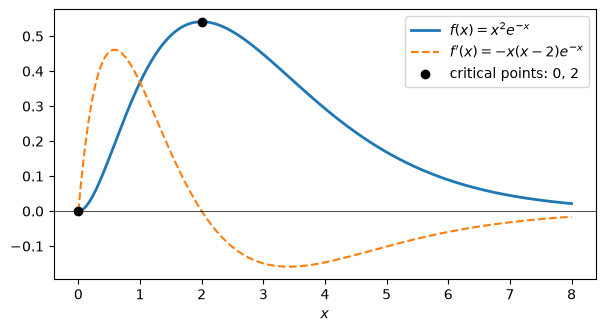

In [220]:
fp_expr = sp.diff(f_expr, x)
crit = sp.solve(fp_expr, x)                         # [0, 2]
fp_np = sp.lambdify(x, fp_expr, 'numpy')
crit_f = np.array(crit, dtype=float)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(xs, f_np(xs), lw=2, label=f"$f(x) = {sp.latex(f_expr)}$")
ax.plot(xs, fp_np(xs), "--", label=f"$f'(x) = {sp.latex(sp.factor(fp_expr))}$")
ax.axhline(0, color="k", lw=0.5)
ax.plot(crit_f, f_np(crit_f), "ko", label="critical points: " + ", ".join(f"${sp.latex(c)}$" for c in crit))
ax.set_xlabel("$x$")
ax.legend()
plt.show()

**Quick look without NumPy:** `sp.plot(f_expr, (x, 0, 8))` draws an expression directly. It is handy for a first look; for anything you want to customise (shading, markers, several panels) use the lambdify + Matplotlib recipe above.

---
# Activity

Four problems; the last one combines integration, NumPy and plotting. Each step says **what your code should do**. Write the code in the empty cell, then run the **check** cell: it prints your results next to the **expected** ones. Open a **Hint** box only when you are stuck; complete code for every step is in the separate notebook `sympy_intro_solutions.ipynb`.

**About `None` and `pass`:** replace `None` by your answer, and delete `pass` once you write the body of a function.

**Useful SymPy for this activity**

| you want to ... | SymPy |
|---|---|
| symbols with assumptions | `sp.Symbol('t', positive=True)`, `sp.symbols('x y', real=True)` |
| simplify / expand / factor | `sp.simplify(e)`, `sp.expand(e)`, `sp.factor(e)` |
| are two expressions equal? | `sp.simplify(e1 - e2) == 0` |
| LaTeX string / pretty print | `sp.latex(e)`, `sp.pprint(e)`, `display(e)` |
| exact roots / numeric root | `sp.solve(e, x)`, `sp.nsolve(e, x, guess)` |
| derivative, Hessian | `sp.diff(e, x)`, `sp.diff(e, x, 2)`, `sp.hessian(F, (x, y))` |
| integral | `sp.integrate(e, x)`, `sp.integrate(e, (x, a, b))` |
| a number | `e.evalf()`, `float(e)` |
| NumPy function | `sp.lambdify(x, e, 'numpy')` |
| RREF, rank, det, null space | `A.rref()`, `A.rank()`, `A.det()`, `A.nullspace()` |
| eigenvalues, eigenspace | `A.eigenvals()`, `(A - lam*sp.eye(3)).nullspace()` |
| matrix vs elementwise product | `A @ B`, `A.multiply_elementwise(B)` |

---
## Problem 1: symbols, functions and printing

**Goal:** build expressions with the right assumptions, write a Python function that builds an expression for you, and print the result in three ways.

**What you will see:** the *same* formula simplifies differently depending on what SymPy knows about the symbols, and one expression has several printed forms.

Run the cell below to create the symbols for this problem (do not change it).

In [221]:
x = sp.Symbol('x', real=True)
t = sp.Symbol('t', positive=True)

### Step 1: assumptions and simplification

Write code that:

1. builds $E_1 = \sqrt{t^2}\,\dfrac{x^2 - 1}{x - 1}$ and stores its simplified form in `E1_simple`;
2. builds $E_2 = \sqrt{x^2}$ and stores its simplified form in `E2_simple`;
3. displays both.

<details><summary><b>Hint</b></summary>

Use `sp.sqrt`, not `np.sqrt`. `sp.simplify(sp.sqrt(t**2) * (x**2 - 1) / (x - 1))`.

</details>

In [222]:
# your code here: replace each None
E1_simple = None
E2_simple = None

In [223]:
# check: compare your results with the expected ones
if E1_simple is None or E2_simple is None:
    print("E1_simple or E2_simple is still None: write the code in the cell above, then run this cell again.")
else:
    print("E1_simple =", E1_simple, "   (expected: t*(x + 1))")
    print("E2_simple =", E2_simple, "   (expected: Abs(x), because x is only known to be real)")
    print("E1 correct:", sp.simplify(E1_simple - t * (x + 1)) == 0)

E1_simple or E2_simple is still None: write the code in the cell above, then run this cell again.


**Questions:**
1. Why does $\sqrt{t^2}$ become $t$ but $\sqrt{x^2}$ become $|x|$?
2. What would $\sqrt{x^2}$ simplify to if you had created `x = sp.Symbol('x')` with **no** assumptions? Try it.

### Step 2: a function that builds expressions

Write a function `make_poly(coeffs, var)`.

**Inputs:** `coeffs`, a list $[c_0, c_1, \ldots, c_n]$, and a symbol `var`.

**Returns** the expression $c_0 + c_1\,\text{var} + c_2\,\text{var}^2 + \cdots + c_n\,\text{var}^n$.

Example: `make_poly([1, -3, 0, 2], x)` gives $2x^3 - 3x + 1$.

<details><summary><b>Hint</b></summary>

Start from `result = 0` and add one term per coefficient in a loop (`coeffs[i]` is $c_i$):

```python
result = 0
for i in range(len(coeffs)):
    result = result + coeffs[i] * var**i
return result
```

Short form (see the Python reminder in Section 1): `return sum(coeffs[i] * var**i for i in range(len(coeffs)))`.

</details>

In [224]:
def make_poly(coeffs, var):
    # Write your code here, then delete the line `pass` below.
    pass

In [225]:
# check: compare your results with the expected ones
P = make_poly([1, -3, 0, 2], x)
if P is None:
    print("make_poly returned None: finish the function (and delete the line `pass`), then run this cell again.")
else:
    print("make_poly([1, -3, 0, 2], x) =", P, "   (expected: 2*x**3 - 3*x + 1)")
    print("make_poly([0, 1], t)**2     =", sp.expand(make_poly([0, 1], t)**2), "   (expected: t**2)")

make_poly returned None: finish the function (and delete the line `pass`), then run this cell again.


### Step 3: three ways to print

For `P = make_poly([1, -3, 0, 2], x)`, write code that:

1. prints `P` with `print`;
2. prints `P` with `sp.pprint`;
3. stores the LaTeX code of `P` in the string `P_tex` and prints it;
4. renders `P_tex` as math with `display(Math("P(x) = " + P_tex))`;
5. renders $\dfrac{d}{dx}P(x)$ as an **equation** `Derivative = result` using `sp.Eq(sp.Derivative(P, x), sp.diff(P, x))`;
6. stores in `P_eq` the LaTeX of the equation $P(x) = 2x^3 - 3x + 1$ inside an `equation` **environment**, and prints it.

<details><summary><b>Hint</b></summary>

`P_tex = sp.latex(P)`. For 6: `sp.latex(sp.Eq(sp.Function('P')(x), P), mode='equation')`.

</details>

In [226]:
# your code here: replace each None by a LaTeX string
P_tex = None
P_eq = None

In [227]:
# check: compare your results with the expected ones
if P_tex is None or P_eq is None:
    print("P_tex or P_eq is still None: write the code in the cell above, then run this cell again.")
else:
    print("P_tex =", P_tex, "   (expected: 2 x^{3} - 3 x + 1)")
    print("P_eq  =", P_eq, "   (expected: \\begin{equation}P{\\left(x \\right)} = 2 x^{3} - 3 x + 1\\end{equation})")

P_tex or P_eq is still None: write the code in the cell above, then run this cell again.


**Questions:**
1. Which of the outputs could you paste back into Python? Which into a LaTeX report?
2. In the plot titles of Section 9, commands like `\int` are written `\\int` inside the f-string. Why? (See "LaTeX output" in the cheat sheet.)

---
## Problem 2: roots and derivatives

**Goal:** find and classify the critical points of

$$f(x) = x^3 - 6x^2 + 9x + 1,$$

find its real root, solve an equation that has **no** formula, and find the minimum of a function of two variables.

**What you will see:** `solve` is perfect for $f'(x) = 0$, but returns an unreadable formula for $f(x) = 0$; `nsolve` gives the number directly.

Run the cell below (do not change it).

In [228]:
x, y = sp.symbols('x y', real=True)
f2 = x**3 - 6*x**2 + 9*x + 1

### Step 1: critical points and the second derivative test

Write code that:

1. computes $f'$ and $f''$ (call them `fp2` and `fpp2`);
2. solves $f'(x) = 0$ and stores the **sorted** list of solutions in `crit2`;
3. builds a list `kinds2` with one string per critical point: `"max"` if $f'' < 0$ there, `"min"` if $f'' > 0$;
4. prints, for each critical point, the point, $f$ there, and its kind.

<details><summary><b>Hint</b></summary>

`crit2 = sorted(sp.solve(fp2, x))`. Then build `kinds2` with a loop:

```python
kinds2 = []
for c in crit2:
    if fpp2.subs(x, c) < 0:
        kinds2.append("max")
    else:
        kinds2.append("min")
```

Short form: `kinds2 = ["max" if fpp2.subs(x, c) < 0 else "min" for c in crit2]`.

</details>

In [229]:
# your code here: replace each None
fp2 = None
fpp2 = None
crit2 = None
kinds2 = None

In [230]:
# check: compare your results with the expected ones
if crit2 is None or kinds2 is None:
    print("crit2 or kinds2 is still None: write the code in the cell above, then run this cell again.")
else:
    print("crit2  =", crit2, "   (expected: [1, 3])")
    print("kinds2 =", kinds2, "   (expected: ['max', 'min'])")
    print("f at the critical points:", [f2.subs(x, c) for c in crit2], "   (expected: [5, 1])")

crit2 or kinds2 is still None: write the code in the cell above, then run this cell again.


### Step 2: exact or numeric roots?

Write code that:

1. displays `sp.solve(f2, x)` and looks at it (do not try to read it all);
2. stores the real root of $f$ as a **number** in `root2`, using `sp.nsolve` with the **initial guess** $x_0 = 0$;
3. stores the solution of $\cos x = x$ in `r_cos`, using `sp.nsolve` with the **initial guess** $x_0 = 1$.

**Why these guesses:** from Step 1, $f$ has a local max $5$ at $x=1$ and a local min $1 > 0$ at $x = 3$, so the only real root is left of $x = 1$; $f(0) = 1 > 0$ and $f(-1) = -15 < 0$, so it lies between $-1$ and $0$. For $\cos x = x$: at $x = 1$, $\cos 1 \approx 0.54 < 1$, and at $x = 0$, $\cos 0 = 1 > 0$, so the solution lies between $0$ and $1$.

<details><summary><b>Hint</b></summary>

`sp.nsolve(f2, x, 0)` and `sp.nsolve(sp.cos(x) - x, x, 1)`. `sp.real_roots(f2)` gives the same root as an exact `CRootOf` object; `.evalf()` turns it into a number.

</details>

In [231]:
# your code here: replace each None
root2 = None
r_cos = None

In [232]:
# check: compare your results with the expected ones
if root2 is None or r_cos is None:
    print("root2 or r_cos is still None: write the code in the cell above, then run this cell again.")
else:
    print("root2 =", sp.N(root2, 10), "   (expected: -0.1038034027)")
    print("r_cos =", sp.N(r_cos, 10), "   (expected: 0.7390851332, the fixed point of cos)")

root2 or r_cos is still None: write the code in the cell above, then run this cell again.


### Step 3: two variables

For $F(x, y) = x^2 + xy + y^2 - 3x$, write code that:

1. computes the gradient `grad` as a list $[\partial F/\partial x,\ \partial F/\partial y]$;
2. solves `grad = 0` (a system of two equations) and stores the result in `crit_xy`;
3. computes the Hessian `H` with `sp.hessian`, and its eigenvalues with `H.eigenvals()`.

<details><summary><b>Hint</b></summary>

`grad = [sp.diff(F_xy, x), sp.diff(F_xy, y)]`. `sp.solve(grad, [x, y])` returns a dict like `{x: ..., y: ...}`. A critical point is a **minimum** when all eigenvalues of the Hessian are positive.

</details>

In [233]:
F_xy = x**2 + x*y + y**2 - 3*x
# your code here: replace each None
grad = None
crit_xy = None
H = None

In [234]:
# check: compare your results with the expected ones
if crit_xy is None or H is None:
    print("crit_xy or H is still None: write the code in the cell above, then run this cell again.")
else:
    print("crit_xy        =", crit_xy, "   (expected: {x: 2, y: -1})")
    print("H              =", H.tolist(), "   (expected: [[2, 1], [1, 2]])")
    print("eigenvals of H =", H.eigenvals(), "   (expected: eigenvalues 1 and 3, each once; dict order may vary)")

crit_xy or H is still None: write the code in the cell above, then run this cell again.


**Questions:**
1. Why is `solve` fine for $f'(x) = 0$ but not useful for $f(x) = 0$? (Compare the degrees.)
2. What happens if you start `nsolve(f2, x, 3)`? Explain with the local minimum at $x = 3$.
3. Is $(2, -1)$ a minimum, a maximum or a saddle point of $F$? How do the eigenvalues of $H$ tell you?

---
## Problem 3: linear algebra

**Goal:** analyse a singular matrix with RREF, rank and null space; diagonalize a matrix with a repeated eigenvalue and compute $A^n$ for symbolic $n$; and see the difference between the matrix product and the elementwise product.

$$B = \begin{pmatrix} 1 & 2 & 3 \\ 4 & 5 & 6 \\ 7 & 8 & 9 \end{pmatrix}, \qquad A = \begin{pmatrix} 4 & 1 & -1 \\ 2 & 5 & -2 \\ 1 & 1 & 2 \end{pmatrix}$$

Run the cell below (do not change it).

In [235]:
B3 = sp.Matrix([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
A3 = sp.Matrix([[4, 1, -1], [2, 5, -2], [1, 1, 2]])
n = sp.Symbol('n', integer=True, nonnegative=True)

### Step 1: RREF, rank, determinant, null space of $B$

Write code that computes and displays:

1. the RREF of $B$ and its pivot columns (`R3, piv3`);
2. the rank `rank3` and the determinant `det3`;
3. a basis `null3` of the null space, and checks that $B v = 0$ for each basis vector $v$.

<details><summary><b>Hint</b></summary>

`R3, piv3 = B3.rref()`, `B3.rank()`, `B3.det()`, `B3.nullspace()`. `null3` is a list of vectors; check each one in a loop: `for v in null3: display(B3 @ v)`.

</details>

In [236]:
# your code here: replace each None
R3, piv3 = None, None
rank3 = None
det3 = None
null3 = None

In [237]:
# check: compare your results with the expected ones
if R3 is None or rank3 is None or det3 is None or null3 is None:
    print("Something is still None: write the code in the cell above, then run this cell again.")
else:
    print("R3    =", R3.tolist(), "   (expected: [[1, 0, -1], [0, 1, 2], [0, 0, 0]])")
    print("piv3  =", piv3, "   (expected: (0, 1))")
    print("rank3 =", rank3, "  det3 =", det3, "   (expected: 2 and 0)")
    print("null3 =", [v.T.tolist()[0] for v in null3], "   (expected: [[1, -2, 1]])")

Something is still None: write the code in the cell above, then run this cell again.


### Step 2: diagonalization, matrix powers and elementwise products

Write code that:

1. diagonalizes $A$: `P3, D3 = A3.diagonalize()`, and checks $A = P D P^{-1}$;
2. computes the symbolic power `An3` $= P D^n P^{-1}$ (simplified), and checks that substituting $n = 5$ gives the same matrix as `A3**5`;
3. computes the **matrix** product `A3 @ A3` and the **elementwise** product `A3.multiply_elementwise(A3)`, stores them in `prod3` and `hadamard3`, and displays both.

<details><summary><b>Hint</b></summary>

`An3 = sp.simplify(P3 @ D3**n @ P3.inv())`, then `An3.subs(n, 5) == A3**5`. `A3**n` directly also works in SymPy; compare.

</details>

In [238]:
# your code here: replace each None
An3 = None
prod3 = None
hadamard3 = None

In [239]:
# check: compare your results with the expected ones
if An3 is None or prod3 is None or hadamard3 is None:
    print("Something is still None: write the code in the cell above, then run this cell again.")
else:
    print("An3[1, 1]           =", An3[1, 1], "   (expected: 5**n)")
    print("An3.subs(n, 5)[0,0] =", An3.subs(n, 5)[0, 0], "   (expected: 1684)")
    print("prod3     =", prod3.tolist(), "   (expected: [[17, 8, -8], [16, 25, -16], [8, 8, 1]])")
    print("hadamard3 =", hadamard3.tolist(), "   (expected: [[16, 1, 1], [4, 25, 4], [1, 1, 4]])")

Something is still None: write the code in the cell above, then run this cell again.


**Questions:**
1. $\det B = 0$, $\operatorname{rank} B = 2$, and the null space has dimension $1$. How are these three facts related (rank-nullity)?
2. The eigenvalue $3$ is a double root. Look at the columns of `P3` that belong to it: why is $A$ still diagonalizable?
3. As $n \to \infty$, which eigenvalue dominates the entries of $A^n$? Read it off `An3`.

---
## Problem 4: integrals, NumPy and plotting

**Goal:** analyse and plot

$$h(x) = (x^2 - 4)\,e^{-x/3} \qquad \text{on } [-3, 12],$$

using **only** symbolic results for every special point, line and number in the figure, and check an exact integral against a numerical one.

**What you will see:** with SymPy doing the algebra, the roots, the critical points, the tangent line and the areas all come out **exact**; `lambdify` turns them into NumPy functions for numerics and plotting.

Run the cell below (do not change it).

In [240]:
x = sp.Symbol('x', real=True)
h4 = (x**2 - 4) * sp.exp(-x / 3)

### Step 1: the symbolic part

Write code that computes:

1. `roots4`: the sorted roots of $h$;
2. `crit4`: the sorted critical points (roots of $h'$), exactly; display them, and their decimal values;
3. `tangent4`: the tangent line at $x_0 = 0$, as an expanded expression;
4. `H4`: an antiderivative of $h$, checked by differentiating: `sp.simplify(sp.diff(H4, x) - h4)` should be `0`;
5. `area4`: the exact value of $\int_{-2}^{2} h\,dx$ (simplified), and its float;
6. `area4_inf`: the exact value of the improper integral $\int_{-2}^{\infty} h\,dx$.

<details><summary><b>Hint</b></summary>

`sorted(sp.solve(h4, x))`; `sorted(sp.solve(sp.diff(h4, x), x), key=float)`; tangent: `h4.subs(x, 0) + sp.diff(h4, x).subs(x, 0) * (x - 0)`; `sp.integrate(h4, x)`; `sp.simplify(sp.integrate(h4, (x, -2, 2)))`; for $\infty$ use `sp.oo`.

</details>

In [241]:
# your code here: replace each None
roots4 = None
crit4 = None
tangent4 = None
H4 = None
area4 = None
area4_inf = None

In [242]:
# check: compare your results with the expected ones
if roots4 is None or crit4 is None or tangent4 is None or H4 is None or area4 is None or area4_inf is None:
    print("Something is still None: write the code in the cell above, then run this cell again.")
else:
    print("roots4   =", roots4, "   (expected: [-2, 2])")
    print("crit4    =", crit4, "   (expected: [3 - sqrt(13), 3 + sqrt(13)])")
    print("tangent4 =", tangent4, "   (expected: 4*x/3 - 4)")
    print("H4' - h4 =", sp.simplify(sp.diff(H4, x) - h4), "   (expected: 0)")
    print("area4    =", round(float(area4), 6), "   (expected: -11.148328, negative because h < 0 on (-2, 2))")
    print("area4_inf=", area4_inf, "   (expected: 18*exp(2/3), about 35.059)")

Something is still None: write the code in the cell above, then run this cell again.


### Step 2: the trapezoid rule with `lambdify`

Write a function `trap(f_np, a, b, N)`.

**Inputs:** a NumPy function `f_np`, the interval $[a, b]$, and the number of sub-intervals $N$.

**Returns** the trapezoid approximation $\displaystyle h\left(\tfrac12 f(x_0) + f(x_1) + \cdots + f(x_{N-1}) + \tfrac12 f(x_N)\right)$ with step $h = (b - a)/N$ and $x_i = a + i\,h$.

Then, for the area of Step 1, $a = -2$ and $b = 2$:

1. make the NumPy function `h4_np = sp.lambdify(x, h4, 'numpy')`;
2. for $N = 10, 20, 40, 80, 160$, print $N$ and the error $|\,\text{trap}(h, -2, 2, N) - \text{area}\,|$, where the area is `float(area4)` from Step 1.

<details><summary><b>Hint</b></summary>

Go through the points $x_0, \ldots, x_N$ one at a time with a `for` loop, and use an `if` to give the two end points the weight $\tfrac12$ (the step is called `step` here so it does not clash with the function $h$):

```python
step = (b - a) / N
total = 0
for i in np.arange(0, N + 1):      # i = 0, 1, ..., N
    xi = a + i * step
    if i == 0 or i == N:           # end points count half
        total = total + f_np(xi) / 2
    else:
        total = total + f_np(xi)
return step * total
```

For the error table, loop over the list `[10, 20, 40, 80, 160]` and call `trap(h4_np, -2, 2, N)` inside the loop.

</details>

In [243]:
def trap(f_np, a, b, N):
    # Write your code here, then delete the line `pass` below.
    pass

# your code here: replace None, then print the error table for a = -2, b = 2
h4_np = None

In [244]:
# check: compare your results with the expected ones
if h4_np is None or trap(np.exp, 0, 1, 10) is None:
    print("h4_np is still None or trap returned None: finish the cell above, then run this cell again.")
else:
    print("trap(h4_np, -2, 2, 10) =", round(float(trap(h4_np, -2, 2, 10)), 6), "   (expected: -11.017285)")
    print("error at N = 160       =", f"{abs(trap(h4_np, -2, 2, 160) - float(area4)):.2e}", "   (expected: 5.13e-04)")

h4_np is still None or trap returned None: finish the cell above, then run this cell again.


### Step 3: the figure

Make **one figure with two panels** side by side, `fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))`:

| panel | what to draw |
|---|---|
| left, `axes[0]` | $h$ on $[-3, 12]$ with label `f"$h(x) = {sp.latex(h4)}$"`; the tangent line at $0$ (dashed) on $[-3, 3]$; the roots as black dots; the critical points as red dots; the region between $h$ and $0$ on $[-2, 2]$ shaded; title with the exact area: `f"$\\int_{{-2}}^{{2}} h\\,dx = {sp.latex(area4)} \\approx {float(area4):.4f}$"` |
| right, `axes[1]` | $h'$ on $[-3, 12]$ with a LaTeX label, the line $y = 0$, and red dots at the critical points (where $h'$ crosses $0$) |

Add $x$ labels and legends to both panels.

<details><summary><b>Steps (open if you need them)</b></summary>

```python
hp_np = sp.lambdify(x, sp.diff(h4, x), 'numpy')
tan_np = sp.lambdify(x, tangent4, 'numpy')
r = np.array(roots4, dtype=float); c = np.array(crit4, dtype=float)
xs = np.linspace(-3, 12, 500); xt = np.linspace(-3, 3, 50)
mask = (xs >= -2) & (xs <= 2)
# axes[0]: plot(xs, h4_np(xs)), plot(xt, tan_np(xt), "--"), plot(r, h4_np(r), "ko"), plot(c, h4_np(c), "ro"),
#          fill_between(xs[mask], h4_np(xs[mask]), alpha=0.3), set_title(...)
# axes[1]: plot(xs, hp_np(xs)), axhline(0), plot(c, hp_np(c), "ro")
```

</details>

In [245]:
# your code here: one figure, two panels

**Questions:**
1. Which critical point is a local minimum and which a local maximum? Confirm with the sign of $h''$ there (one line of SymPy).
2. Compute $\lim_{x \to \infty} h(x)$ with `sp.limit` and compare with the plot.
3. Why is `area4` negative while `area4_inf` is positive? Use the plot.